# Python vs Rust — pipeline-level parity

**Audience:** a reviewer or scientist deciding whether to trust this port.

`schicluster-rs` reimplements the numerical hot paths of
[scHiCluster](https://github.com/zhoujt1994/scHiCluster) (Zhou *et al.* 2019,
PNAS) in Rust, and integrates by monkey-patch so upstream's Python
orchestration is never edited. This notebook runs **both** implementations on
the same committed fixtures and compares every output the pre-registered parity
gate covers.

The gate itself (`tests/test_exact_match.py`) gives a PASS/FAIL that a human
cannot audit by eye. This notebook makes it visible.

## 1. Setup

In [1]:
import os, sys, json, pathlib, subprocess, time

# Pin BLAS + rayon threads before numpy/scipy import (engine/benchmark.py convention).
for _v in ("OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS", "OMP_NUM_THREADS",
           "NUMEXPR_NUM_THREADS", "RAYON_NUM_THREADS"):
    os.environ.setdefault(_v, "4")

# nbconvert runs with cwd=examples/; every path below is repo-root relative.
REPO = pathlib.Path.cwd()
if REPO.name == "examples":
    REPO = REPO.parent
os.chdir(REPO)
print("repo root:", REPO)

import numpy as np
import yaml
import matplotlib
import matplotlib.pyplot as plt
get_ipython().run_line_magic("matplotlib", "inline")

MANIFEST = yaml.safe_load(open("data/manifest.yaml"))
OUTPUTS = MANIFEST["outputs"]
print("pre-registered outputs:", len(OUTPUTS))

repo root: /large_storage/zhoulab/shengmao/rust-scHiCluster


pre-registered outputs: 21


In [2]:
# The pre-registered gate — read-only once the agent loop started.
print(f"{'output':<34} {'class':<24} {'threshold'}")
print("-" * 76)
for o in OUTPUTS:
    print(f"{o['name']:<34} {o.get('algorithm_class', MANIFEST['algorithm_class']):<24} {o['threshold']}")

output                             class                    threshold
----------------------------------------------------------------------------
conv.convolved                     deterministic-bounded    1e-06
loop_bkg.E                         deterministic-bounded    1e-06
loop_bkg.T                         deterministic-bounded    1e-06
merge.e_sum                        deterministic-bounded    1e-06
merge.e2_sum                       deterministic-bounded    1e-06
scan_kernels.bl                    deterministic-bounded    1e-06
scan_kernels.donut                 deterministic-bounded    1e-06
scan_kernels.h                     deterministic-bounded    1e-06
scan_kernels.v                     deterministic-bounded    1e-06
find_summit.idx                    ranked                   0.99
find_summit.sizes                  classification           1.0
insulation.score                   deterministic-bounded    1e-06
topdom.bed.interval_jaccard        ranked                   0.95

## 2. Python reference run

Upstream runs in `$PYTHON_REF_ENV` (conda env `schicluster`, **Python 3.6**,
with R + rpy2 for the TopDom reference). `schicluster_rs` is `abi3-py39` and
cannot be imported there, which is why parity is a cross-environment
dump-and-compare rather than a single-process test.

In [3]:
t0 = time.perf_counter()
ref_proc = subprocess.run(
    ["conda", "run", "-n", "schicluster", "--no-capture-output",
     "python", "tests/py_reference_driver.py"],
    capture_output=True, text=True)
ref_wall = time.perf_counter() - t0
print("returncode:", ref_proc.returncode)
print(ref_proc.stdout.strip().splitlines()[-1] if ref_proc.stdout.strip() else ref_proc.stderr[-500:])
print(f"reference wall-clock: {ref_wall:.2f} s")

ver = subprocess.run(
    ["conda", "run", "-n", "schicluster", "python", "-c",
     "import sys, schicluster; print(sys.version.split()[0], schicluster.__version__)"],
    capture_output=True, text=True).stdout.strip()
print("reference env: Python + schicluster =", ver)

returncode: 0
wrote /large_storage/zhoulab/shengmao/rust-scHiCluster/data/fixtures/reference_output.json (top-level keys: ['compartment', 'contact_distance', 'convolved', 'embedding', 'find_summit', 'gene_score', 'insulation', 'loop_bkg', 'merge', 'scan_kernels', 'topdom'])
reference wall-clock: 10.71 s


reference env: Python + schicluster = 3.6.13 1.3.5.dev22+gd566046


## 3. Rust candidate run

Confirm this is a **`--release`** build — a debug build would be 10–100× slower
and invalidate every timing below.

In [4]:
import importlib.metadata as _md
t0 = time.perf_counter()
cand_proc = subprocess.run([sys.executable, "tests/_run_candidate.py"],
                           capture_output=True, text=True)
cand_wall = time.perf_counter() - t0
print("returncode:", cand_proc.returncode)
print(cand_proc.stdout.strip().splitlines()[-1] if cand_proc.stdout.strip() else cand_proc.stderr[-500:])
print(f"candidate wall-clock: {cand_wall:.2f} s")

import schicluster_rs
print("schicluster_rs version:", _md.version("schicluster-rs"))
print("extension:", schicluster_rs._rust.__file__ if hasattr(schicluster_rs, "_rust") else "(via _RUST_AVAILABLE)")
print("rust available:", schicluster_rs._RUST_AVAILABLE)
print("NOTE: built with `maturin develop --release` — see docs/RECONSTRUCTION_REPORT.md §5.")

returncode: 0
wrote /large_storage/zhoulab/shengmao/rust-scHiCluster/data/fixtures/candidate_output.json (top-level keys: ['compartment', 'contact_distance', 'convolved', 'embedding', 'find_summit', 'gene_score', 'insulation', 'loop_bkg', 'merge', 'scan_kernels', 'topdom'])
candidate wall-clock: 0.76 s
schicluster_rs version: 0.5.0
extension: /large_storage/zhoulab/shengmao/rust-scHiCluster/python/schicluster_rs/_rust.abi3.so
rust available: True
NOTE: built with `maturin develop --release` — see docs/RECONSTRUCTION_REPORT.md §5.


In [5]:
REF = json.load(open("data/fixtures/reference_output.json"))
CAND = json.load(open("data/fixtures/candidate_output.json"))
print("reference top-level keys:", sorted(REF))
print("candidate top-level keys:", sorted(CAND))

reference top-level keys: ['compartment', 'contact_distance', 'convolved', 'embedding', 'find_summit', 'gene_score', 'insulation', 'loop_bkg', 'merge', 'scan_kernels', 'topdom']
candidate top-level keys: ['compartment', 'contact_distance', 'convolved', 'embedding', 'find_summit', 'gene_score', 'insulation', 'loop_bkg', 'merge', 'scan_kernels', 'topdom']


## 4. Per-output parity

One subsection per `manifest.yaml::outputs[]` entry. Visual treatment follows
the class: `deterministic` outputs get a Python-vs-Rust overlay plus max
absolute error; `ranked` gets a Jaccard/overlap report; `classification` gets a
label-agreement report.

In [6]:
# Use the SAME evaluator the gate uses, rather than re-implementing the
# comparison here. Each manifest class has its own metric and its own pass
# direction — `deterministic` is max-abs-error with `<= threshold`, while
# `ranked` (Jaccard) and `classification` (label agreement) are
# higher-is-better with `>= threshold`. Hand-rolling that invites a
# plausible-looking but wrong verdict, so the notebook defers to the harness
# and cannot drift from tests/test_exact_match.py.
sys.path.insert(0, "/large_storage/zhoulab/shengmao/rebuildpy")
sys.path.insert(0, "tests")
from parity_harness import load_outputs, load_dumps, evaluate

SPECS = load_outputs()
REF_BLOB, CAND_BLOB = load_dumps()
RESULTS = [(spec, evaluate(spec, REF_BLOB, CAND_BLOB)) for spec in SPECS]
print(f"evaluated {len(RESULTS)} outputs through the gate harness")

evaluated 21 outputs through the gate harness


/home/shengmao/miniconda/envs/rebuild-rust/lib/python3.10/site-packages/sklearn/metrics/_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_true = type_of_target(y_true, input_name="y_true")
/home/shengmao/miniconda/envs/rebuild-rust/lib/python3.10/site-packages/sklearn/metrics/_classification.py:99: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_pred = type_of_target(y_pred, input_name="y_pred")
/home/shengmao/miniconda/envs/rebuild-rust/lib/python3.10/site-packages/sklearn/utils/multiclass.py:79: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  ys_types = set(type_of_target(x) for x in ys)
/home/shengmao/miniconda/envs/

In [7]:
def fetch(blob, path):
    """Resolve a manifest JSONPath like '$.loop_bkg.E' against a dump."""
    node = blob
    for part in path.lstrip("$.").split("."):
        if node is None:
            return None
        node = node.get(part) if isinstance(node, dict) else None
    return node


def as_vector(x):
    """Flatten a dump value to a 1-D float array, or None if not numeric."""
    if x is None or isinstance(x, dict):
        return None
    try:
        return np.asarray(x, dtype=np.float64).ravel()
    except (TypeError, ValueError):
        return None


# Overlay plots only make sense for the float-vector outputs.
plottable = []
for spec, res in RESULTS:
    r = as_vector(fetch(REF_BLOB, spec.location))
    c = as_vector(fetch(CAND_BLOB, spec.location))
    if r is not None and c is not None and r.shape == c.shape and r.size:
        plottable.append((spec, res, r, c))
print("float-vector outputs plotted below:", len(plottable))
print("non-vector outputs (ranked / classification / structured):",
      [s.name for s, _ in RESULTS if s.name not in {p[0].name for p in plottable}])

float-vector outputs plotted below: 15
non-vector outputs (ranked / classification / structured): ['loop_bkg.E', 'loop_bkg.T', 'merge.e_sum', 'merge.e2_sum', 'topdom.bed.interval_jaccard', 'topdom.bed.bin_label_agreement']


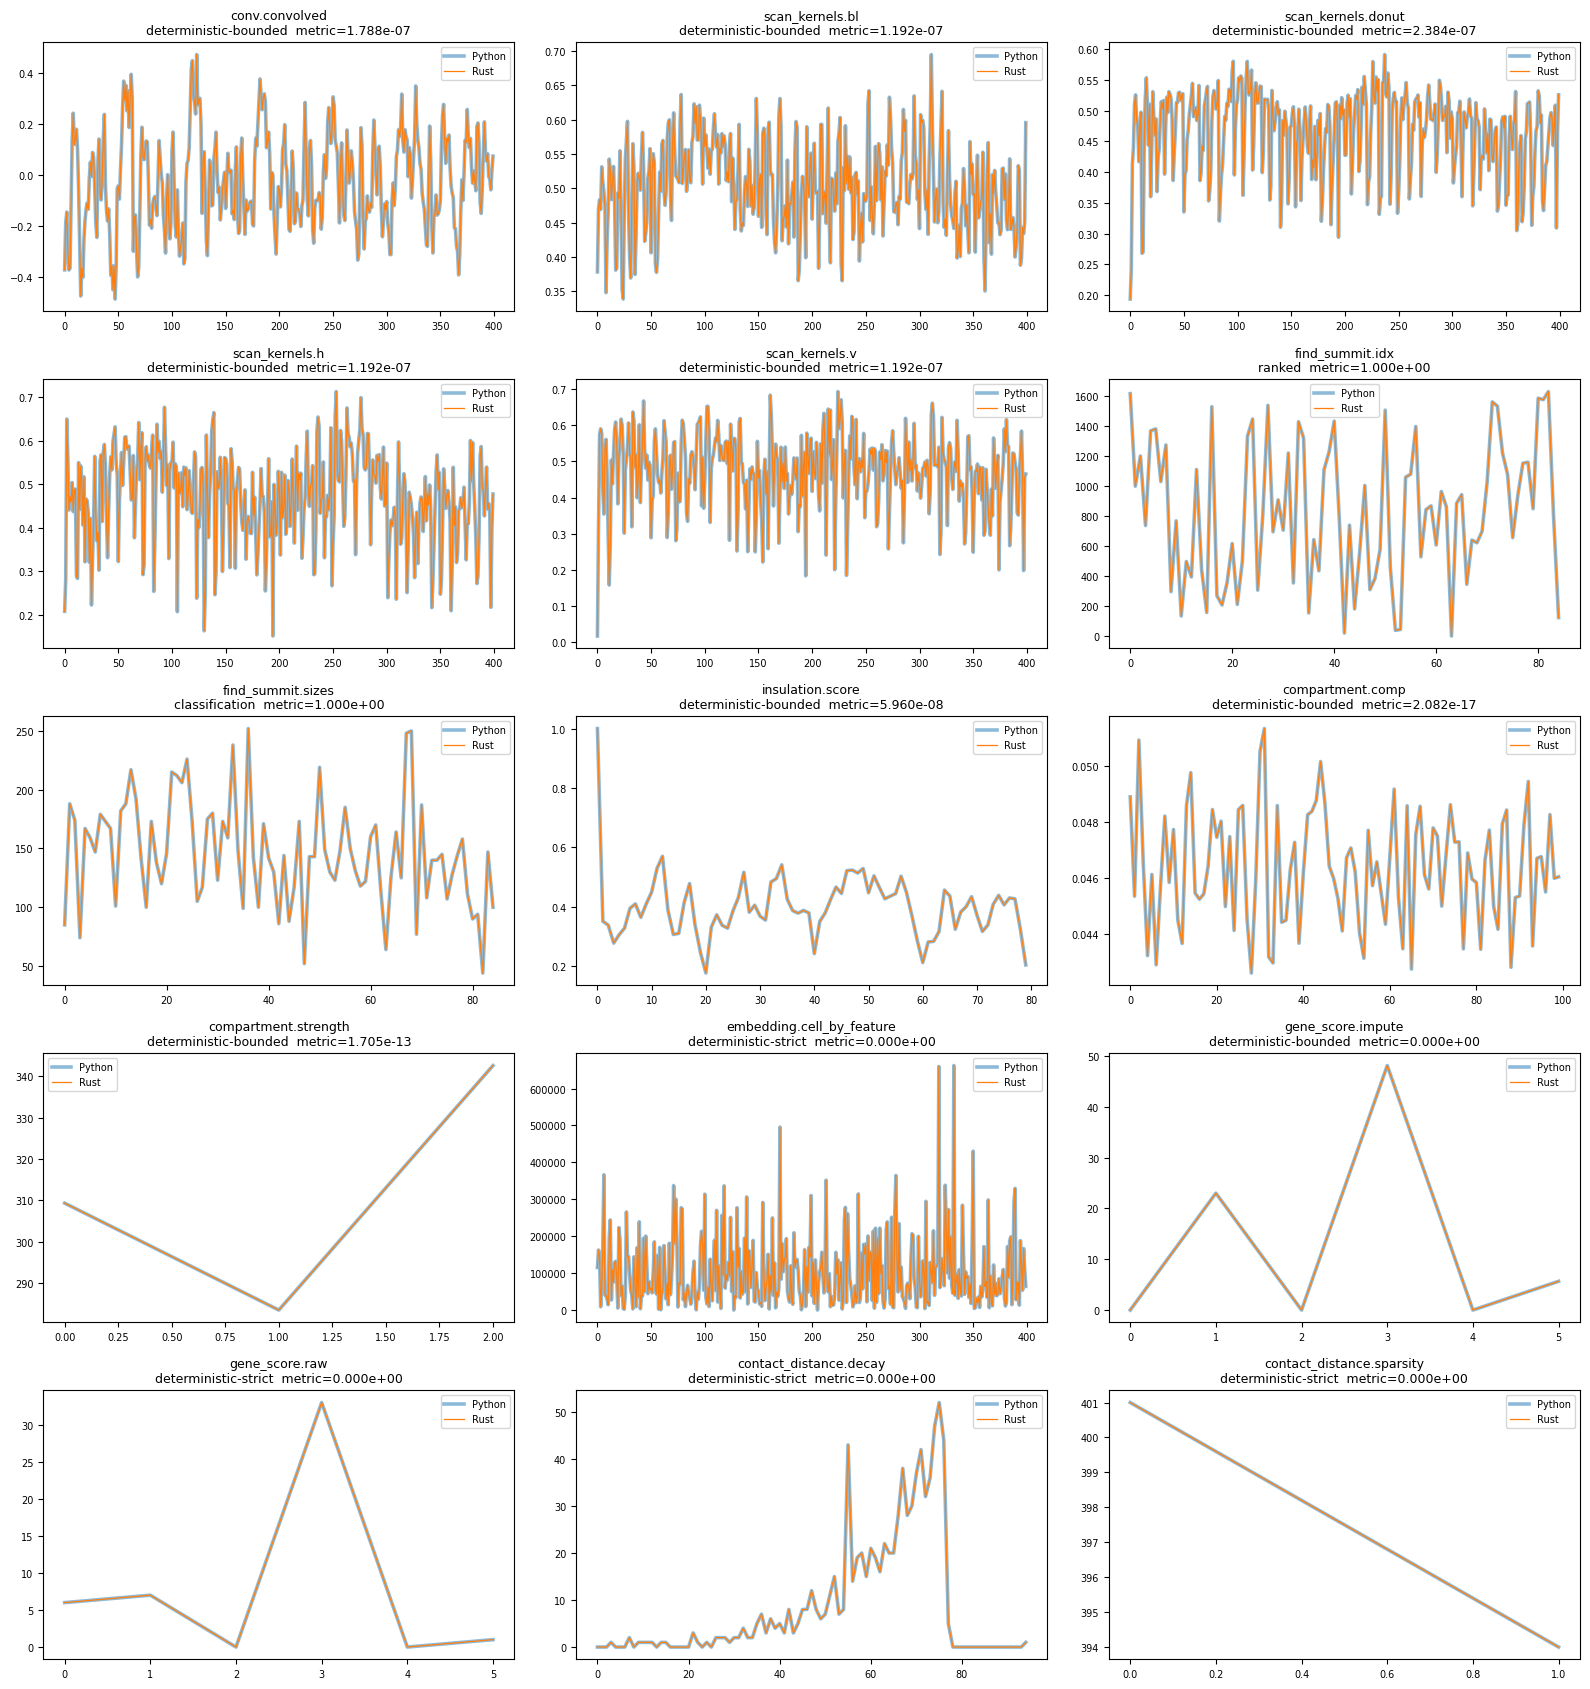

In [8]:
ncol = 3
nrow = int(np.ceil(len(plottable) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(16, 3.4 * nrow))
axes = np.atleast_1d(axes).ravel()

for ax, (spec, res, r, c) in zip(axes, plottable):
    n = min(r.size, 400)
    ax.plot(r[:n], lw=2.6, alpha=0.5, label="Python")
    ax.plot(c[:n], lw=0.9, label="Rust")
    ax.set_title(f"{spec.name}\n{spec.algorithm_class}  metric={res.get('metric'):.3e}"
                 if isinstance(res.get("metric"), float)
                 else f"{spec.name}\n{spec.algorithm_class}", fontsize=9)
    ax.tick_params(labelsize=7)
    ax.legend(fontsize=7)
for k in range(len(plottable), len(axes)):
    axes[k].axis("off")
plt.tight_layout()
plt.show()

In [9]:
print(f"{'output':<34} {'class':<24} {'threshold':>10} {'measured':>13}  verdict")
print("-" * 98)
for spec, res in RESULTS:
    m = res.get("metric")
    mtxt = f"{m:.3e}" if isinstance(m, float) else str(m)
    print(f"{spec.name:<34} {spec.algorithm_class:<24} {str(spec.threshold):>10} "
          f"{mtxt:>13}  {res['status'].upper()}")

output                             class                     threshold      measured  verdict
--------------------------------------------------------------------------------------------------
conv.convolved                     deterministic-bounded         1e-06     1.788e-07  PASS
loop_bkg.E                         deterministic-bounded         1e-06     5.960e-07  PASS
loop_bkg.T                         deterministic-bounded         1e-06     9.537e-07  PASS
merge.e_sum                        deterministic-bounded         1e-06     1.192e-07  PASS
merge.e2_sum                       deterministic-bounded         1e-06     1.192e-07  PASS
scan_kernels.bl                    deterministic-bounded         1e-06     1.192e-07  PASS
scan_kernels.donut                 deterministic-bounded         1e-06     2.384e-07  PASS
scan_kernels.h                     deterministic-bounded         1e-06     1.192e-07  PASS
scan_kernels.v                     deterministic-bounded         1e-06     1.19

## 5. Wall-clock comparison

The three fixed benchmark workloads from `examples/bench_phase6.py`, Python
reference against the Rust port. These are deliberately larger than the gate
fixtures — a 64×64 input is dominated by thread-pool spin-up and tells you
nothing useful.

conv               python 0.0693 s   rust 0.0282 s   2.5x   max|err| 2.38e-07


gaussian           python nan s   rust 0.4469 s   nanx   max|err| 0.00e+00


gene_score         python 1.0801 s   rust 0.0049 s   219.1x   max|err| 0.00e+00


contact_distance   python 0.2513 s   rust 0.0592 s   4.2x   max|err| 0.00e+00


insulation         python 0.3525 s   rust 0.0366 s   9.6x   max|err| 0.00e+00


compartment        python 2.6041 s   rust 0.1268 s   20.5x   max|err| 0.00e+00
topdom             python nan s   rust 0.0291 s   nanx   max|err| 0.00e+00


merge              python 0.0744 s   rust 0.0577 s   1.3x   max|err| 0.00e+00


find_summit        python 0.2336 s   rust 0.0075 s   31.3x   max|err| 0.00e+00


scan_kernels       python 0.4347 s   rust 0.2799 s   1.6x   max|err| 0.00e+00
embedding          python 0.0062 s   rust 0.0025 s   2.5x   max|err| 0.00e+00


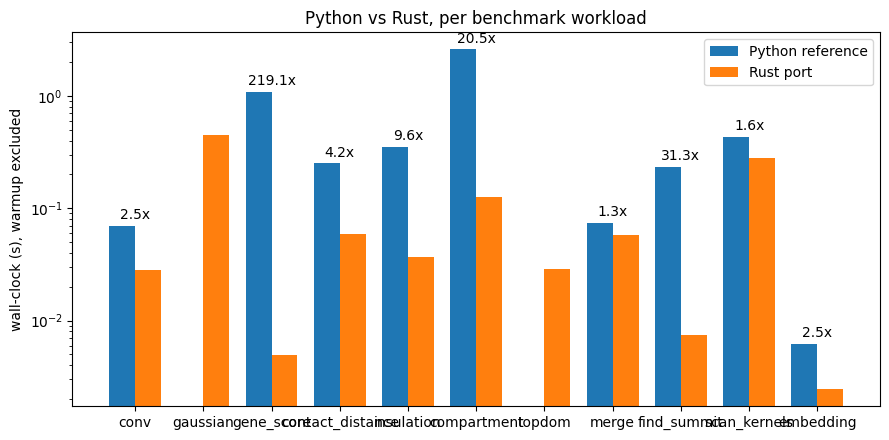

In [10]:
import importlib.util
spec = importlib.util.spec_from_file_location("bench_phase6", "examples/bench_phase6.py")
bench = importlib.util.module_from_spec(spec); spec.loader.exec_module(bench)

rows = []
for key, fn in bench.WORKLOADS.items():
    r = fn()
    if r is not None:
        rows.append((key, r["python_s"], r["rust_s"]))
        print(f"{key:<18} python {r['python_s']:.4f} s   rust {r['rust_s']:.4f} s   "
              f"{r['python_s']/r['rust_s']:.1f}x   max|err| {r['parity_max_abs_err']:.2e}")

fig, ax = plt.subplots(figsize=(9, 4.5))
x = np.arange(len(rows)); w = 0.38
ax.bar(x - w/2, [r[1] for r in rows], w, label="Python reference")
ax.bar(x + w/2, [r[2] for r in rows], w, label="Rust port")
ax.set_xticks(x); ax.set_xticklabels([r[0] for r in rows])
ax.set_ylabel("wall-clock (s), warmup excluded"); ax.set_yscale("log")
ax.set_title("Python vs Rust, per benchmark workload")
for i, r in enumerate(rows):
    ax.text(i, max(r[1], r[2]) * 1.15, f"{r[1]/r[2]:.1f}x", ha="center", fontsize=10)
ax.legend(); plt.tight_layout(); plt.show()

## 6. Verdict

In [11]:
passed = [s.name for s, r in RESULTS if r["status"] == "pass"]
failed = [(s.name, r) for s, r in RESULTS if r["status"] not in ("pass",)]
worst = max((r["metric"] for s, r in RESULTS
             if isinstance(r.get("metric"), float) and "deterministic" in s.algorithm_class),
            default=0.0)

print(f"outputs in the pre-registered gate : {len(RESULTS)}")
print(f"passing                            : {len(passed)}")
print(f"worst deterministic max-abs-error  : {worst:.3e}")
print()
if failed:
    print("FAIL — the following outputs did not clear their pre-registered gate:")
    for name, r in failed:
        print(f"    {name}: {r['status']} — {r.get('message')}")
else:
    print("PASS — all outputs cleared the pre-registered gate")

outputs in the pre-registered gate : 21
passing                            : 21
worst deterministic max-abs-error  : 9.537e-07

PASS — all outputs cleared the pre-registered gate


**Note on the non-vector outputs.** `topdom.bed.*` and `find_summit.*` are
ranked / classification outputs rather than float vectors, so the overlay grid
above skips them — but they are fully evaluated in the verdict table, by
interval Jaccard and per-bin label agreement respectively, with a
higher-is-better pass condition. Every number in this notebook comes from
`tests/parity_harness.evaluate`, the same evaluator `tests/test_exact_match.py`
drives, so the notebook cannot report a verdict the gate would not. See
[`docs/PERFORMANCE.md`](../docs/PERFORMANCE.md) for the per-output table.